In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

import mne
from tqdm import tqdm

# UDFs

In [ ]:
def timeSeries_plot(X, y, randomInt):
    randomSub = X[randomInt, : , :]
    labelSub = int(y[randomInt])
    plt.figure(figsize=(15, 5))
    for i in range(0, randomSub.shape[0]):
        plt.plot(randomSub[i, :], label = f"Electrode {i}")
        plt.title(f"EEG Signal for Subject {randomInt}, Repetition R1, Motor Imagery ({labelSub}) - 125Hz Sampling Rate")
        plt.xlabel("Sample Points")
        plt.ylabel("Voltage(muV)")
        plt.legend()
    plt.show()


In [4]:
data = np.load("../eeg_processed/eeg_data.npz")
X, y = data['X'], data['y']
print(f"X (n_trails, n_channels, n_samples) : {X.shape}")
print(f"y (n_trails, ) : {y.shape}")

X (n_trails, n_channels, n_samples) : (1799, 16, 500)
y (n_trails, ) : (1799,)


In [5]:
randomInt = random.randint(0, X.shape[0])

In [6]:
print("Maximum Values (Electrode-Wise) Mu Volts: ")
print(X[1, :, :].max(axis = 1))
print("*" * 200)

print("Minimum Values (Electrode-Wise) Mu Volts: ")
print(X[1, :, :].min(axis = 1))
print("*" * 200)


print("Mean Values (Electrode-Wise) Mu Volts: ")
print(X[1, :, :].mean(axis = 1))
print("*" * 200)

Maximum Values (Electrode-Wise) Mu Volts: 
[7.20679016e+01 1.14041473e+02 2.11021667e+02 1.23135659e-22
 1.92725048e+01 1.28032181e+02 3.59302368e+01 5.10368080e+01
 1.39039574e+01 2.37390427e+02 4.66127052e+01 1.23135659e-22
 1.12098923e+02 2.90875912e+01 2.68483143e+01 3.71037712e+01]
********************************************************************************************************************************************************************************************************
Minimum Values (Electrode-Wise) Mu Volts: 
[-6.56923218e+01 -1.23710693e+02 -2.07726288e+02 -2.18275288e-22
 -2.72122211e+01 -1.09775208e+02 -4.44863815e+01 -4.25163841e+01
 -1.70179386e+01 -2.34638168e+02 -5.48070908e+01 -2.18275288e-22
 -1.25650826e+02 -3.95991249e+01 -2.40246544e+01 -5.77693253e+01]
********************************************************************************************************************************************************************************************************
Mean V

# Correction


1. Ocular Correction
2. Baseline Correction

3. Artifacts Removal
    - Artifacts are parts of the recorded signal that arise from sources other than the source of interest

    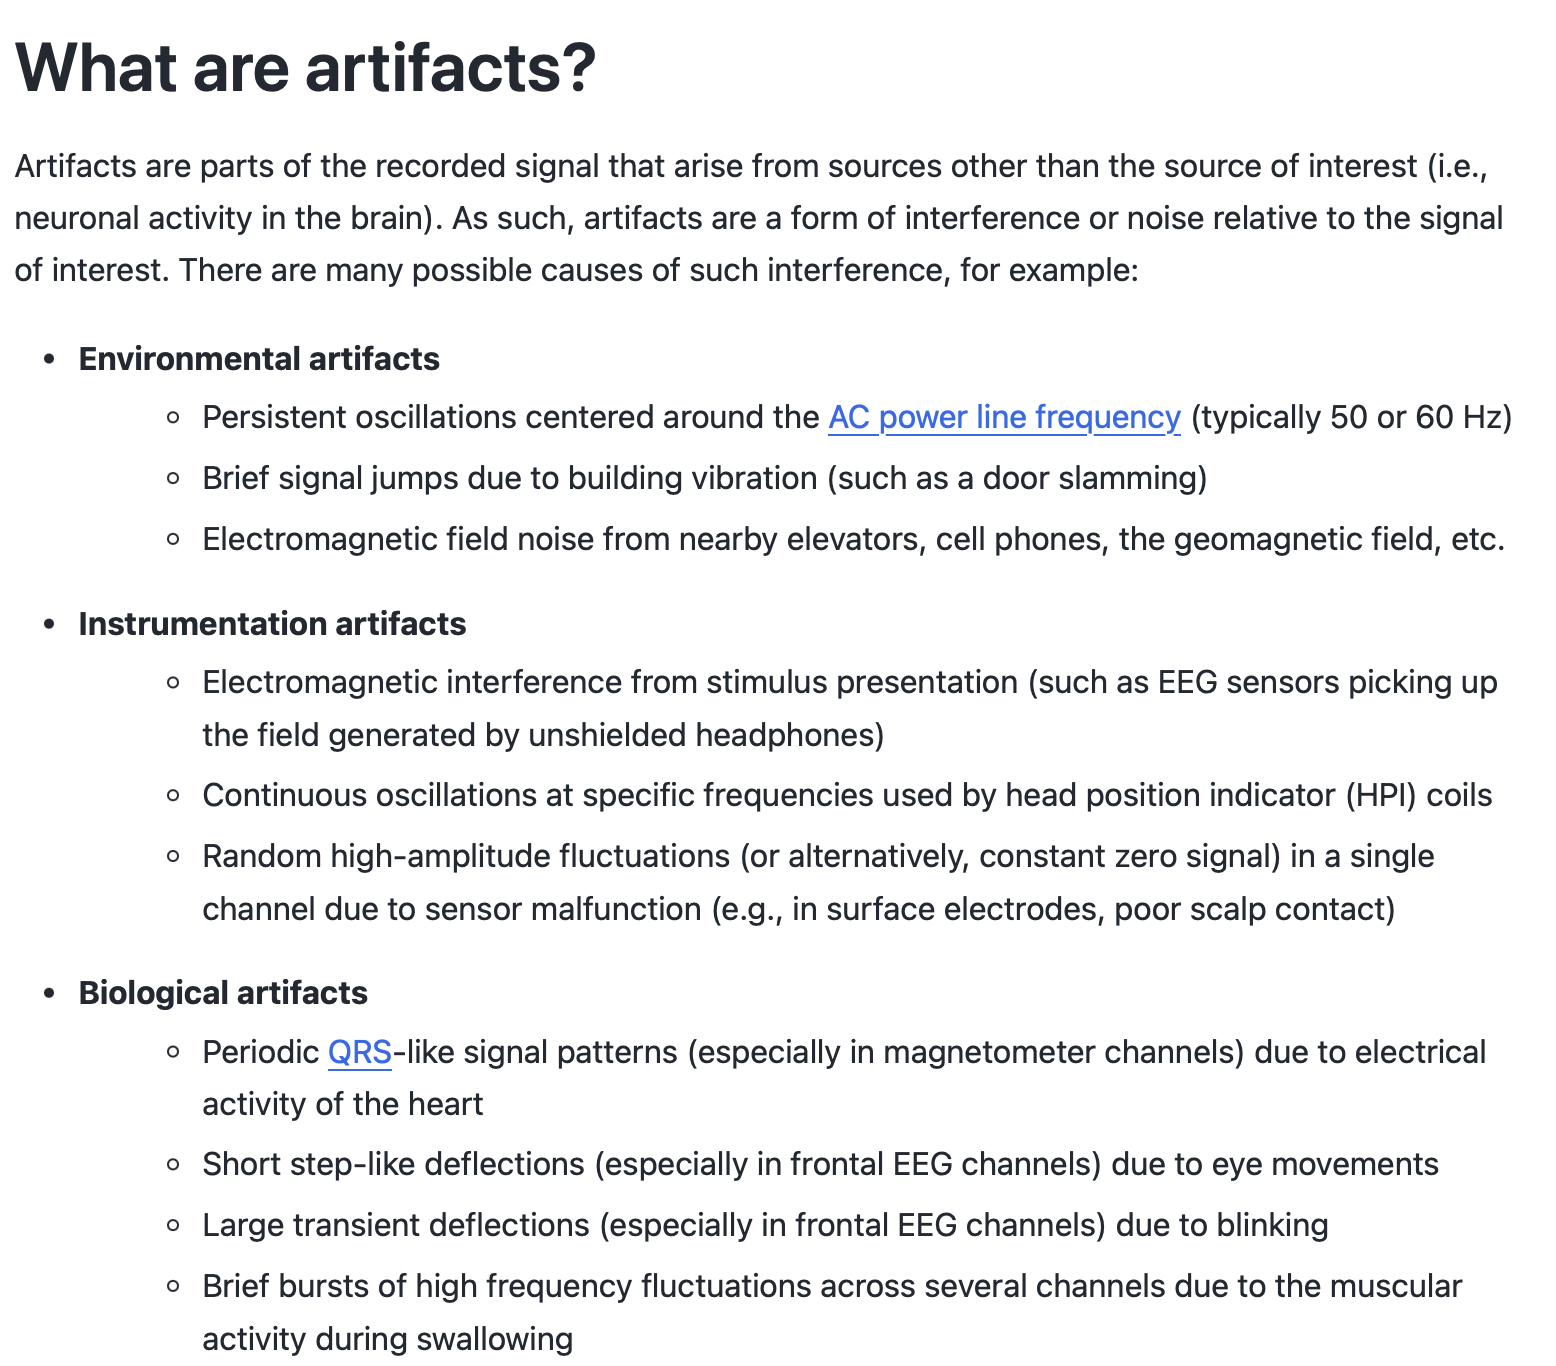


### 1. Artifact - Power line Noise

We are using mne - notch filter in EEG to remove 50 Hz or 60 Hz power line noise, which is a common artifact from electrical equipment that can obscure true EEG activity

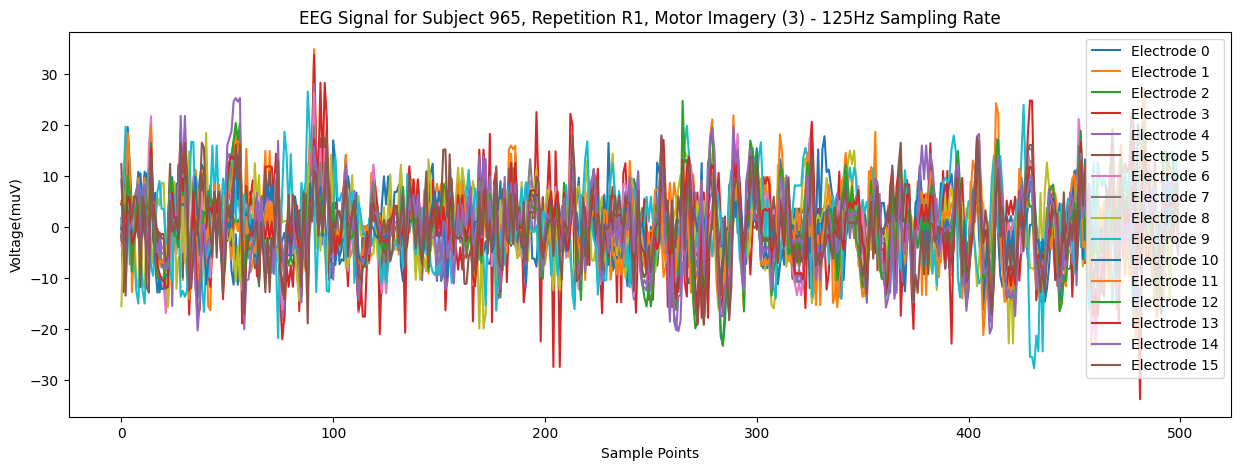

In [7]:
timeSeries_plot(X, y, randomInt)

Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 825 samples (6.600 s)



/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_31548/4140463475.py:1: RuntimeWarning: filter_length (825) is longer than the signal (500), distortion is likely. Reduce filter length or filter a longer signal.
  X_filtered = mne.filter.notch_filter(X, Fs= 125, freqs = 60)
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 881 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 1151 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1457 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 2177 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 2591 tasks    

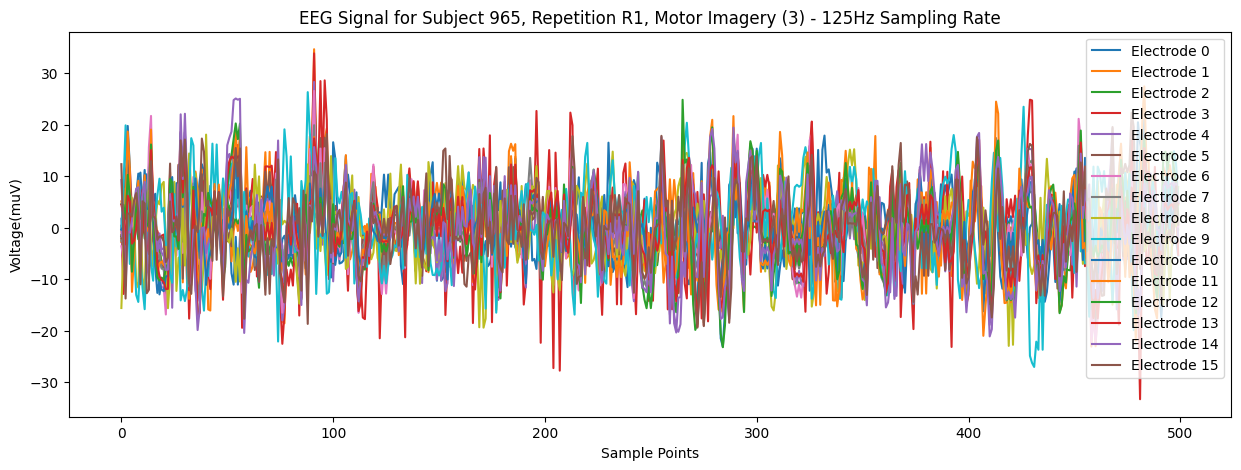

In [8]:
X_filtered = mne.filter.notch_filter(X, Fs= 125, freqs = 60)

timeSeries_plot(X_filtered, y, randomInt)

### 2. Heartbeat Artifacts (ECG) 

# EEG Signal Decomposition Technique in Python

1. Frequency-based decomposition
2. Time-frequency decomposition
3. Source-based decomposition
4. Mode-based decomposition

## 1. Frequency Based Decomposition

- This is a classic method that seperates EEG data into standard brainwave frequency bands: 
    - delta, 
    - theta, 
    - alpha, 
    - beta, 
    - gamma

- Techniques :
 
    - Filtering
    - Fast Fourier Transform (FFT)
    - Multi-Taper Method 


# 1. Filtering 

Here, we are going to use Band-Pass filtering

Band-Pass filtering : Keeps only the frequency range of interest.

- Typically 0.5 - 40 Hz for motor imagery / cognitive tasks
- Sometimes 8-30 Hz (mu & beta rhythms) 


## Digitial Butterworth Concept

Goal: Keep frequencies of interest (e.g., 1-50 Hz) and remove unwanted noise 

EEG frequency bands of interest

- Delta : 0.5-4 Hz
- Theta : 4-8 Hz
- Alpha : 8-13 Hz
- Beta  : 13-30 Hz
- Gamma : 30-50 Hz  


What is the Order Parameter in Butterworth Filter

- EEG needs to preserve signal shape and avoid distortion.

- Too high order = sharper cutoff but may:

    - Introduce ringing artifacts (oscillations in the signal).
    - Increase computational load.

- Too low order = filter is too “gentle” → noise leaks in.

- 👉 That’s why for EEG, order 2–6 is commonly used.

- Example:
    - Order 2–4: Smooth filtering (good for general EEG preprocessing).
    - Order 6–8: Sharper transitions (used when you must strictly isolate bands like alpha 8–13 Hz).



## 1. Filtering - Using Butterworth filter

-  Band-pass Butterworth filter for EEG

In [9]:
from scipy.signal import butter, filtfilt
def butter_bandpass(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

def butter_highpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high')
    y = filtfilt(b, a, data, axis=-1)
    return y




### 1. Original Signal

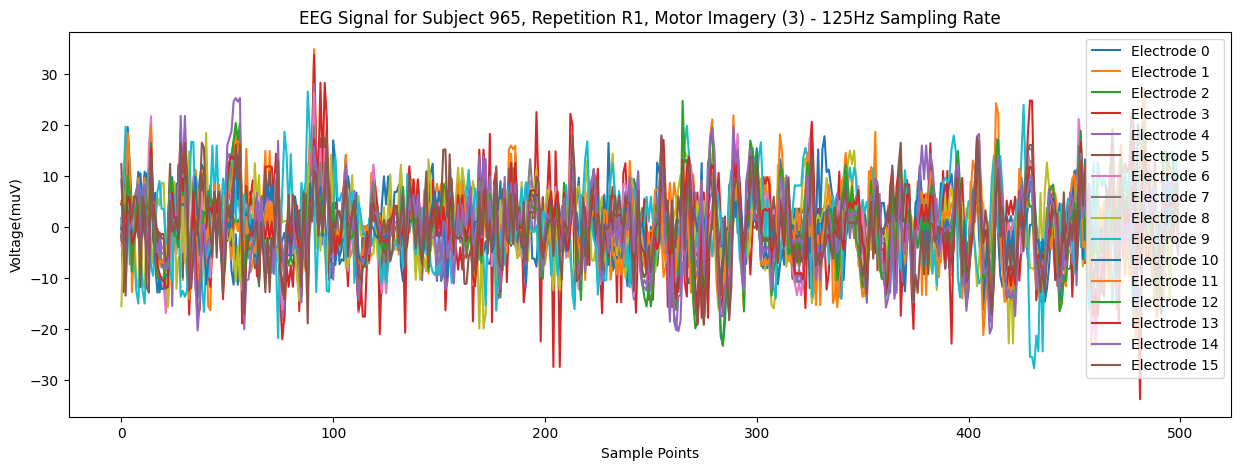

In [10]:
timeSeries_plot(X, y, randomInt)

## 2. Capturing Delta Waves

 - The slowest brainwaves, typically associated with deep relaxation and restorative sleep, with frequency range of 0.4 to 8 Hz

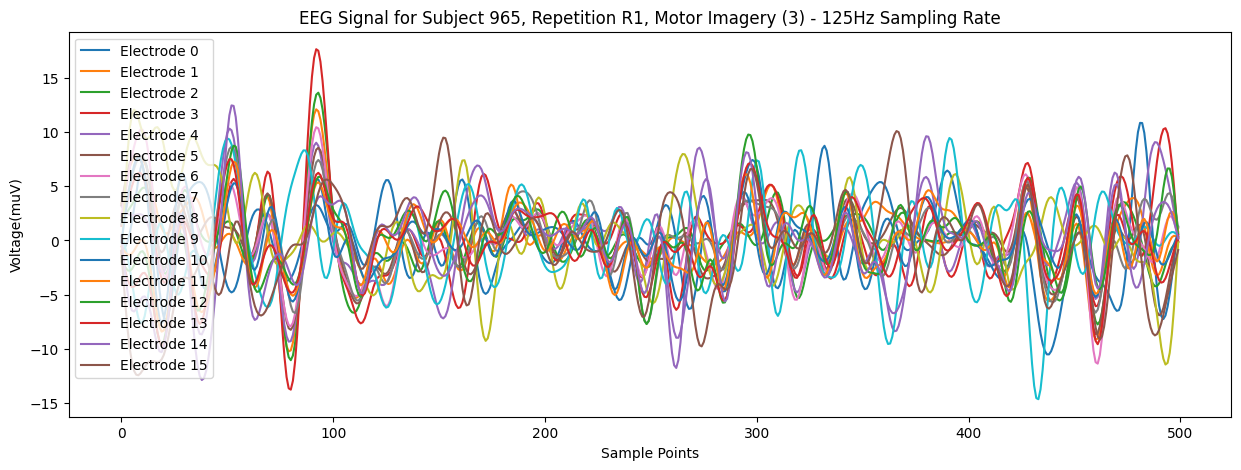

In [11]:
X_filtered = butter_bandpass(X, 
                       lowcut = 0.5, 
                       highcut = 8, 
                       fs = 125)
timeSeries_plot(X_filtered, y, randomInt)

## 3. Theta Waves

- Often observed during drowsiness, hyponsis, or just before falling asleep, with a frequency range of 4 to 8 Hz

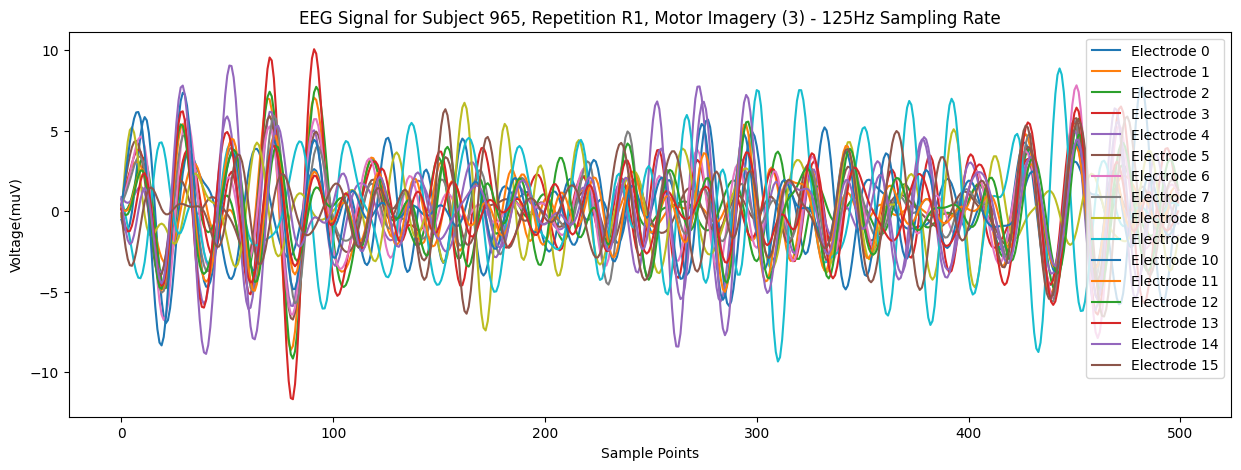

In [12]:
X_filtered = butter_bandpass(X, 
                       lowcut = 4, 
                       highcut = 8, 
                       fs = 125)

timeSeries_plot(X_filtered, y, randomInt)

## 4. Alpha Waves

- These act as a "frequency bridge" between conscious thought (Beta) and subconscious (Theta), usually appearing when a person 
is calmand often when their eyes are closed. The frequency range is 8 to 12 Hz

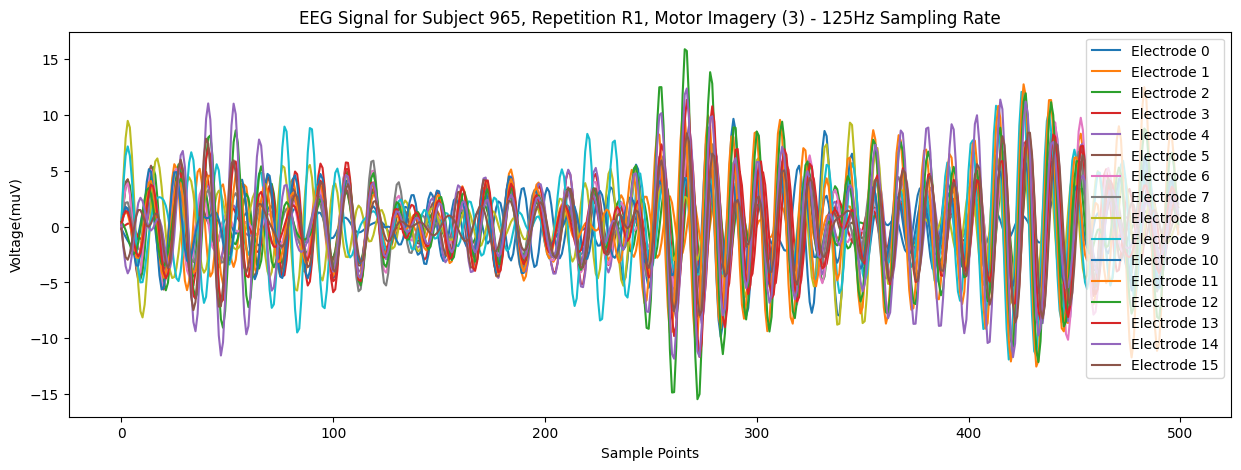

In [13]:
X_filtered = butter_bandpass(X, 
                       lowcut = 8, 
                       highcut = 12, 
                       fs = 125)

timeSeries_plot(X_filtered, y, randomInt)

## 5. Beta Waves

- Commonly seen during wakefulness and associated with cognitive tasks such as reasoning, calculation, reading, communication and thinking. The frequency range is 12 to 40 Hz


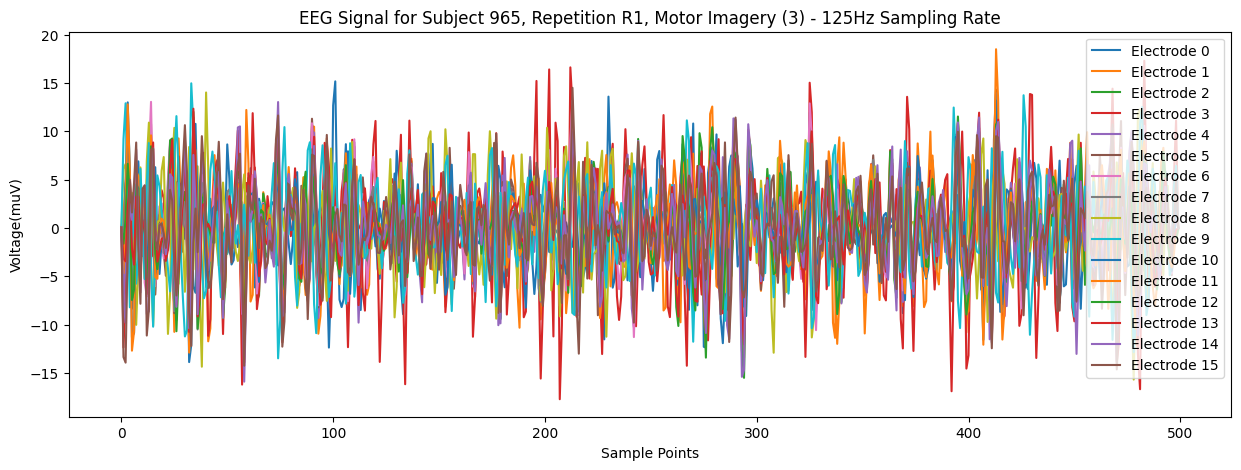

In [14]:
X_filtered = butter_bandpass(X, 
                       lowcut = 12, 
                       highcut = 40, 
                       fs = 125)

timeSeries_plot(X_filtered, y, randomInt)

## 6. Gamma Waves

A newer area of research in neuroscience, Gamma waves are crucial for learning, memory, and sensory processing, acting as a binding tool for new information. The frequency range is 40 to 100 Hz

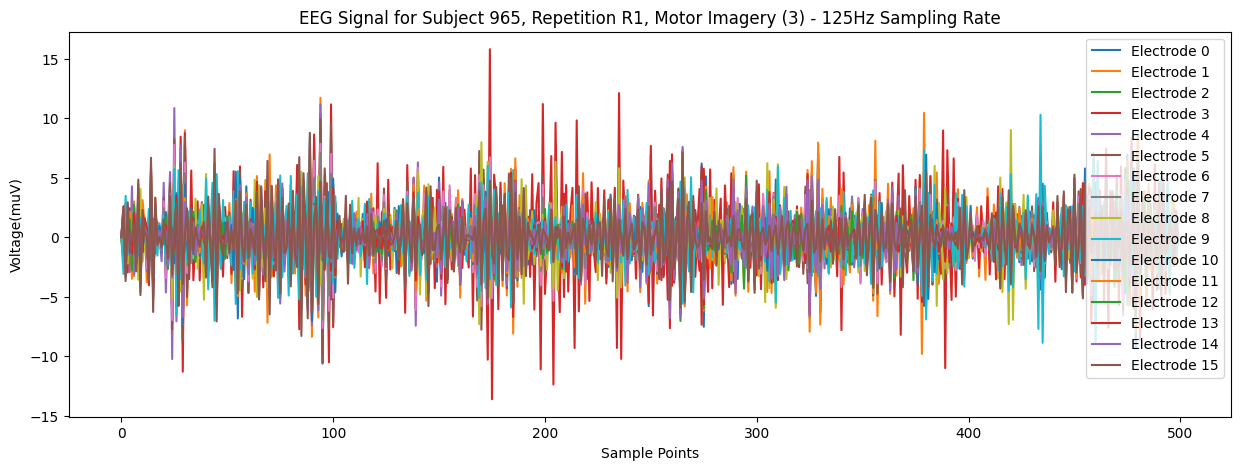

In [15]:
X_filtered = butter_highpass_filter(X, 
                       cutoff= 40, 
                       fs = 125)

timeSeries_plot(X_filtered, y, randomInt)

# 2. Estimate the Power Spectral Density (PSD)

PSD estimation is the process of calculating the signal's power distribution across different frequencies. Two common PSD estimation methods are

1. Fast Fourier Transform (FFT) : This algorithm efficiently computes the discrete Fourier Transform. For EEG, the FFT is applied to each segmented epoch, and the magnitude squared is taken to estimate the power. However, simple FFT-based estimates can be noisy

2. Welch's method : This technique improves on the FFT by dividing the signal into overlapping segments, computing the periodogram (FFT - based PSD estimate) for each segment, and then averaging the periodograms. This process reduces noise and variance, resulting in a smoother, more robust power spectrum.


- Convert the EEG Signal from the time domain to the frequency domain to analyze power at different frequencies

In [16]:
from scipy.signal import welch

#### Doubt :Why we are using Trapezoidal Rule of Integration

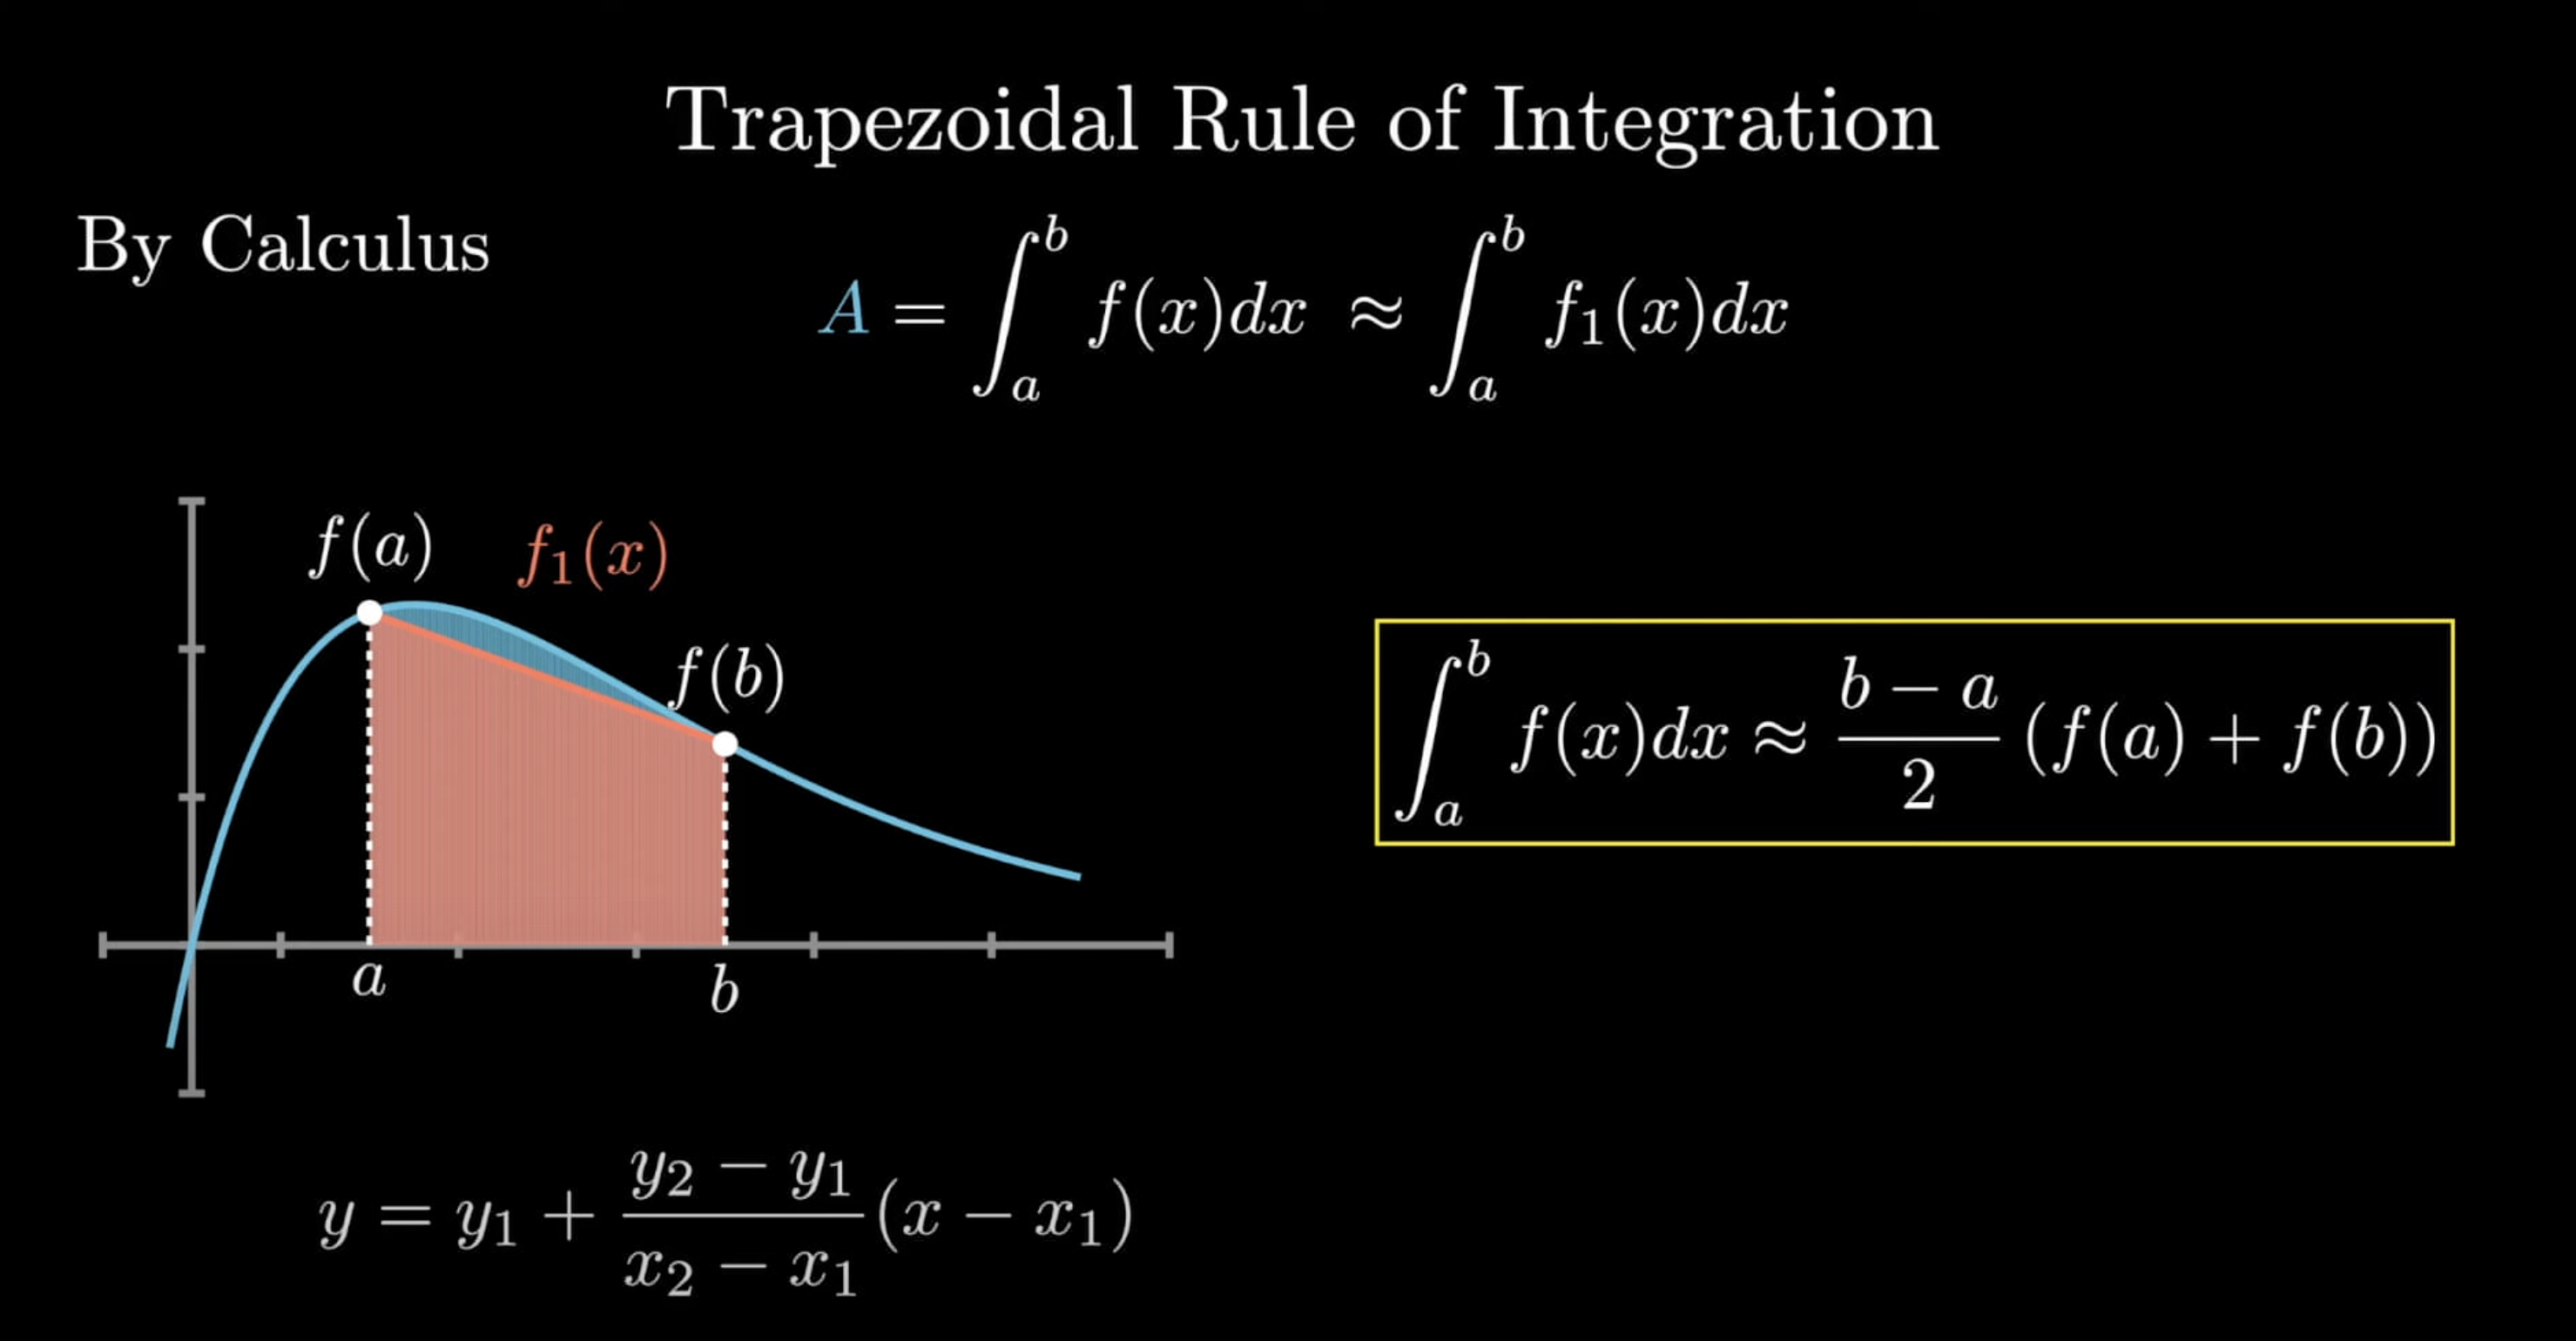

In [17]:
def bandpower(eeg_signal, fs, band):
    """Compute band power in given frequency band"""
    f, Pxx = welch(eeg_signal, fs, nperseg=fs*2)
    idx = np.logical_and(f >= band[0], f <= band[1])
    return np.trapz(Pxx[idx], f[idx]), f, Pxx

bands = {'mu': [8,13], 'beta':[13,30]}

In [18]:
master_sample_freq, master_sample_power = [], []
for samples in tqdm(range(0, X.shape[0])):
    sample_freq, sample_power = [], []
    for channels in range(0, X.shape[1]):
        f, Pxx = welch(X[samples, channels, :], fs = 125, nperseg=125*2)
        sample_freq.append(f) # Appending frequency
        sample_power.append(Pxx) # Appending Power

    master_sample_freq.append(sample_freq) # Appending master frequency
    master_sample_power.append(sample_power) # Appending master power

master_sample_freq = np.array(master_sample_freq)
master_sample_power = np.array(master_sample_power)

100%|██████████| 1799/1799 [00:01<00:00, 1256.75it/s]


In [19]:
def plot_psd_all_channels(freqs, power, figsize=(15, 10)):
    """
    Plot Power Spectral Density (PSD) for all EEG channels in subplots.

    Parameters
    ----------
    freqs : ndarray
        Frequency values (shape: [n_channels, n_freqs] or [n_freqs]).
    power : ndarray
        Power values (shape: [n_channels, n_freqs]).
    figsize : tuple
        Size of the whole figure.
    """
    n_channels = power.shape[0]
    n_cols = int(np.ceil(np.sqrt(n_channels)))
    n_rows = int(np.ceil(n_channels / n_cols))

    # If freqs is 1D, replicate for each channel
    if freqs.ndim == 1:
        freqs = np.tile(freqs, (n_channels, 1))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=True, sharey=True)
    axes = axes.flatten()

    for ch in range(n_channels):
        axes[ch].plot(freqs[ch], power[ch])
        axes[ch].set_title(f"Channel {ch}")
        axes[ch].set_xlabel("Frequency (Hz)")
        axes[ch].set_ylabel("Power (dB)")

    # Hide any unused subplots
    for ax in axes[n_channels:]:
        ax.axis("off")

    plt.suptitle("Power Spectral Density (PSD) - All Channels", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


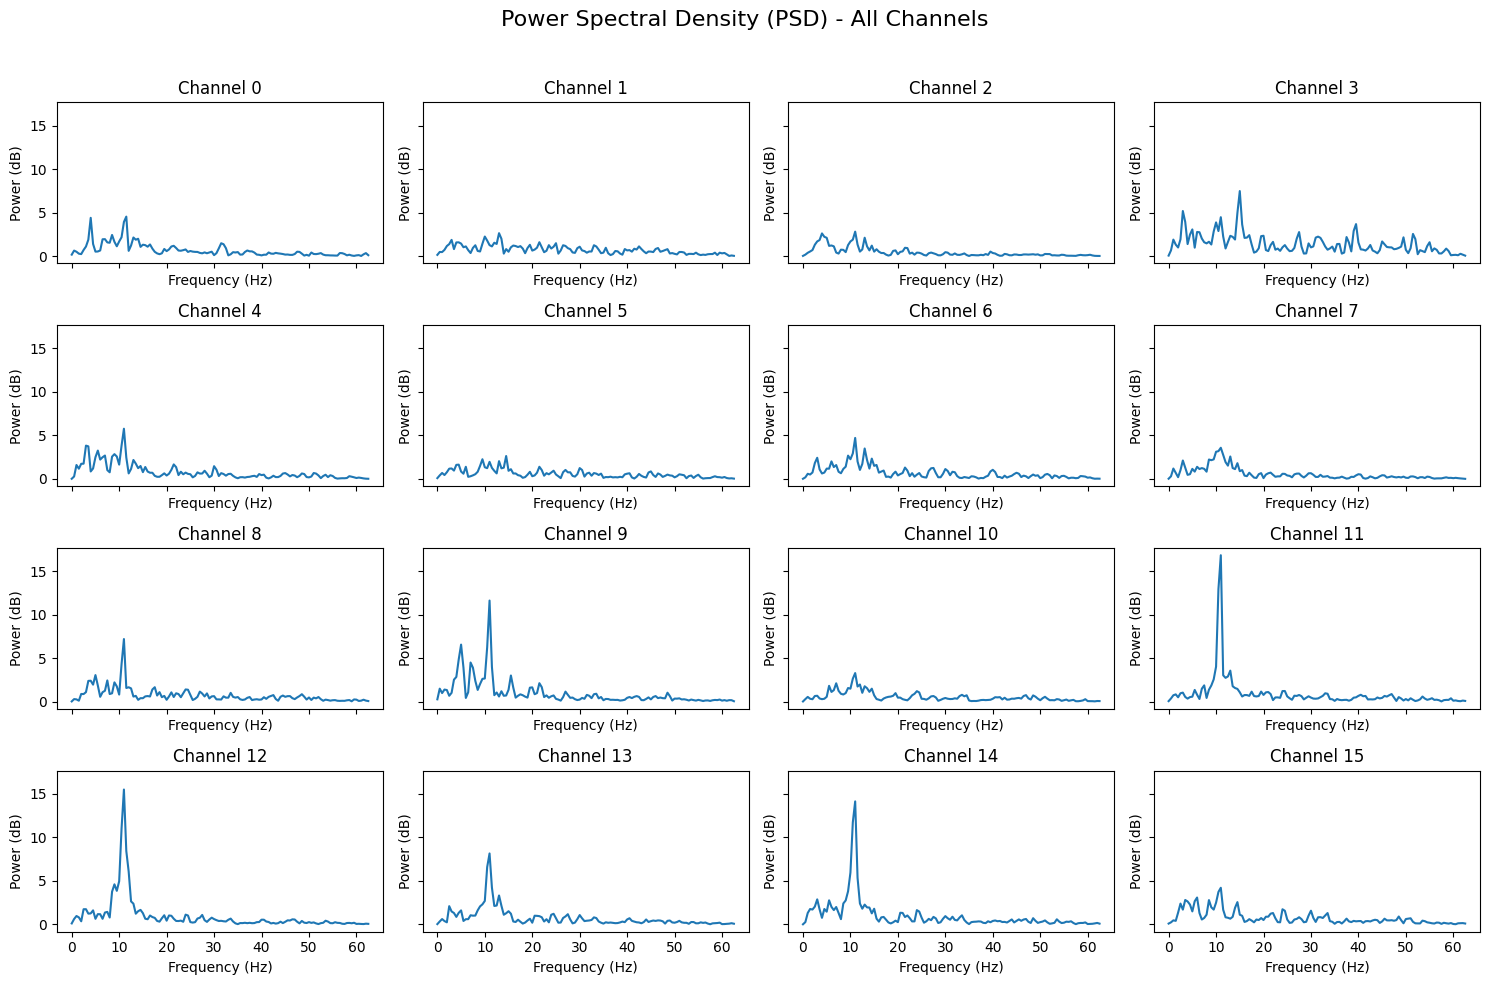

In [20]:
plot_psd_all_channels(master_sample_freq[randomInt, :, :], 
    master_sample_power[randomInt, : , : ]
)

# Generating Time-Related Features

In [ ]:
from scipy.stats import skew, kurtosis

def extract_time_features(X : np.array):
    """
        Function : this function return time-related features
        args :
            input X : input array (n_channel * n_samples)
            output features : pd.DataFrame
    """
    features = pd.DataFrame()
    channels = df.shape[0]
    chls = [i for i in range(0, channels)] 
    for ch in chls:
        features["elect_"+str(ch)+'_mean'] = [X[ch, :].mean()]
        features["elect_"+str(ch)+'_var'] = [X[ch, :].var()]
        features["elect_"+str(ch)+'_skew'] = [skew(X[ch, :])]
        features["elect_"+str(ch)+'_kurt'] = [kurtosis(X[ch, :])]
    return features


time_features = [extract_time_features(X[i, : , : ]) for i in tqdm(range(0, X.shape[0]))]
master_time_related_features = pd.concat(time_features)

In [26]:
master_time_related_features

,elect_0_mean,elect_0_var,elect_0_skew,elect_0_kurt,elect_1_mean,elect_1_var,elect_1_skew,elect_1_kurt,elect_2_mean,elect_2_var,...,elect_13_skew,elect_13_kurt,elect_14_mean,elect_14_var,elect_14_skew,elect_14_kurt,elect_15_mean,elect_15_var,elect_15_skew,elect_15_kurt
0,-0.068341,135.744561,"[1.529856320867407, -0.3188031560878338, -0.20...","[2.5983620756279695, -0.9624921392112582, -1.1...",-0.127946,264.893399,"[-0.8110229482760507, 0.3473335058957254, -0.9...","[0.18380074798077128, -1.130218139534455, 0.70...",-0.266892,129.192154,...,"[-0.15059045408882205, 0.32519304631359863, 1....","[-0.11358803274584606, -0.07655466633328523, 2...",-0.117847,136.12453,"[0.688877147480076, -0.5853332987797557, -0.84...","[0.054071209018656585, -0.756156953149369, 0.6...",0.103251,96.913695,"[0.7521484234051568, 0.8596258329321348, 0.832...","[-1.0152798845040587, -0.7769121164362782, -0...."
0,-0.068341,135.744561,"[1.529856320867407, -0.3188031560878338, -0.20...","[2.5983620756279695, -0.9624921392112582, -1.1...",-0.127946,264.893399,"[-0.8110229482760507, 0.3473335058957254, -0.9...","[0.18380074798077128, -1.130218139534455, 0.70...",-0.266892,129.192154,...,"[-0.15059045408882205, 0.32519304631359863, 1....","[-0.11358803274584606, -0.07655466633328523, 2...",-0.117847,136.12453,"[0.688877147480076, -0.5853332987797557, -0.84...","[0.054071209018656585, -0.756156953149369, 0.6...",0.103251,96.913695,"[0.7521484234051568, 0.8596258329321348, 0.832...","[-1.0152798845040587, -0.7769121164362782, -0...."
0,-0.068341,135.744561,"[1.529856320867407, -0.3188031560878338, -0.20...","[2.5983620756279695, -0.9624921392112582, -1.1...",-0.127946,264.893399,"[-0.8110229482760507, 0.3473335058957254, -0.9...","[0.18380074798077128, -1.130218139534455, 0.70...",-0.266892,129.192154,...,"[-0.15059045408882205, 0.32519304631359863, 1....","[-0.11358803274584606, -0.07655466633328523, 2...",-0.117847,136.12453,"[0.688877147480076, -0.5853332987797557, -0.84...","[0.054071209018656585, -0.756156953149369, 0.6...",0.103251,96.913695,"[0.7521484234051568, 0.8596258329321348, 0.832...","[-1.0152798845040587, -0.7769121164362782, -0...."
0,-0.068341,135.744561,"[1.529856320867407, -0.3188031560878338, -0.20...","[2.5983620756279695, -0.9624921392112582, -1.1...",-0.127946,264.893399,"[-0.8110229482760507, 0.3473335058957254, -0.9...","[0.18380074798077128, -1.130218139534455, 0.70...",-0.266892,129.192154,...,"[-0.15059045408882205, 0.32519304631359863, 1....","[-0.11358803274584606, -0.07655466633328523, 2...",-0.117847,136.12453,"[0.688877147480076, -0.5853332987797557, -0.84...","[0.054071209018656585, -0.756156953149369, 0.6...",0.103251,96.913695,"[0.7521484234051568, 0.8596258329321348, 0.832...","[-1.0152798845040587, -0.7769121164362782, -0...."
0,-0.068341,135.744561,"[1.529856320867407, -0.3188031560878338, -0.20...","[2.5983620756279695, -0.9624921392112582, -1.1...",-0.127946,264.893399,"[-0.8110229482760507, 0.3473335058957254, -0.9...","[0.18380074798077128, -1.130218139534455, 0.70...",-0.266892,129.192154,...,"[-0.15059045408882205, 0.32519304631359863, 1....","[-0.11358803274584606, -0.07655466633328523, 2...",-0.117847,136.12453,"[0.688877147480076, -0.5853332987797557, -0.84...","[0.054071209018656585, -0.756156953149369, 0.6...",0.103251,96.913695,"[0.7521484234051568, 0.8596258329321348, 0.832...","[-1.0152798845040587, -0.7769121164362782, -0...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,-0.068341,135.744561,"[1.529856320867407, -0.3188031560878338, -0.20...","[2.5983620756279695, -0.9624921392112582, -1.1...",-0.127946,264.893399,"[-0.8110229482760507, 0.3473335058957254, -0.9...","[0.18380074798077128, -1.130218139534455, 0.70...",-0.266892,129.192154,...,"[-0.15059045408882205, 0.32519304631359863, 1....","[-0.11358803274584606, -0.07655466633328523, 2...",-0.117847,136.12453,"[0.688877147480076, -0.5853332987797557, -0.84...","[0.054071209018656585, -0.756156953149369, 0.6..